In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.neighbors import KernelDensity

from msi.gaussian_mixture.gaussian_mixture_model import ConditionalGMM
from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files

24-01-17 05:39:12   imports.py INF   Setting up healpy to run on 256 CPUs 


# network predictions

### choose a run

### v3

In [3]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# # base_dir = "/Users/arne/data/DESY3/models/v3/"

In [4]:
# # clustering only

# # legacy vanilla
# # model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# # new vanilla
# # model_dir = "2023-08-17_08-50-56_resnet_vanilla"

# # Jacobian unlike the identity
# # model_dir = "2023-08-17_08-23-47_resnet_vanilla"

# # mean subtracted from all maps
# # model_dir = "2023-08-17_08-38-03_resnet_vanilla"

# # mean subtracted and divide by std for all maps
# model_dir = "2023-08-17_08-19-09_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [5]:
# # clustering only, with and without survey systematics
# model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# n_steps = 50000

# param_labels = ["Om", "s8", "bg", "n_bg"]
# param_latex = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial_point = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

# fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = load_preds(base_dir, model_dir, n_steps)

# # without survey systematics
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}_no_survey_systematics.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     no_survey_systematics_fidu_vali_preds = f["fiducial/vali/pred"][:]
    
# print(no_survey_systematics_fidu_vali_preds.shape)


In [6]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [7]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### v4

In [8]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

In [9]:
# # clustering only

# # large_scales (8 Mpc/h)
# model_dir = "2023-08-25_05-40-02_resnet_vanilla"

# # large scales (12 Mpc/h) and first redshift bin only
# model_dir = "2023-08-29_08-42-16_resnet_vanilla"

# large scales (12 Mpc/h) and third redshift bin only
# model_dir = "2023-08-30_04-21-53_resnet_vanilla"

# # extra large scales (8 Mpc/h, but no factor of pi as with Al)
# model_dir = "2023-08-30_09-31-59_resnet_vanilla"

# GRF, 8 Mpc/h "physical"
# model_dir = "grf/2023-09-06_03-29-03_resnet_vanilla"
# shorter run
# model_dir  = "grf/2023-09-06_09-08-40_resnet_vanilla"
# slightly different network architectures
# model_dir = "grf/2023-09-07_08-08-00_resnet_vanilla"
# model_dir = "grf/2023-09-07_08-09-35_resnet_vanilla"
# only 1st noise realization
# model_dir = "grf/2023-09-07_23-47-11_resnet_vanilla"
# fixed numpy seed
# model_dir = "grf/2023-09-08_07-32-58_resnet_vanilla"

# original data, 8 Mpc/h "physical", for direct comparison with immediately above
# model_dir = "2023-09-06_09-45-08_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "bg", "n_bg"]

In [10]:
# lensing only

# large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [11]:
# # combined probes

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 10000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v5

In [12]:
# # clustering (linear bias)
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/linear_bias"
# model_dir = "2023-10-02_19-48-47_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]

In [13]:
# # clustering (quadratic bias)
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v5/quadratic_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/quadratic_bias_v2"
# model_dir = "2023-10-03_00-16-59_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg", "bg2", "n_bg2"]

In [14]:
# clustering (stochasticity)
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/stochasticity"

# n_steps = 40000
# params = ["Om", "s8", "bg", "n_bg"]

In [15]:
# lensing

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [16]:
# combined

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

In [17]:
# lensing
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# MSE loss
# model_dir = "mse/2024-01-08_03-05-03_resnet_vanilla"

# likelihood loss
# model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

In [18]:
# # clustering
# conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
# base_dir = "/pscratch/sd/a/athomsen/run_files/v6/clustering_only"

# # # delta loss

# # # MSE loss
# # model_dir =

# # # likelihood loss
# model_dir = "mse/2024-01-08_10-05-55_resnet_vanilla"

# n_steps = 40000
# params = ["Om", "s8", "w0", "bg", "n_bg"]

In [19]:
n_params = len(params)

### general

In [20]:
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_gaussian_mix"

In [21]:
# out_dir = os.path.join(base_dir, model_dir)

# preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

# with h5py.File(preds_file, "r") as f:
#     # fiducial
#     fidu_train_preds = f["fiducial/train/pred"][:]
#     # fidu_vali_preds = f["fiducial/vali/pred"][:]

#     # grid
#     # grid_preds = f["grid/pred"][:]
#     # grid_cosmos = f["grid/cosmo"][:]
#     # grid_sobol = f["grid/i_sobol"][:]

In [22]:
# fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)
# # fidu_train_preds, fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps, return_training=True)



# out_dir = os.path.join(base_dir, model_dir)
# label = f"{n_steps}_gaussian_mix"

In [23]:
file_dict = input_output.load_preds(base_dir, model_dir, n_steps)

fidu_preds = file_dict["fiducial/vali/pred"]
grid_preds = file_dict["grid/pred"]
grid_cosmos = file_dict["grid/cosmo"]

# only relevant for the likelihood loss
n_params = len(params)
fidu_preds = fidu_preds[...,:n_params]
grid_preds = grid_preds[...,:n_params]

# combine the example and cosmology axes
grid_preds = np.concatenate(grid_preds, axis=0)
grid_cosmos = np.repeat(grid_cosmos, grid_preds.shape[0]//grid_cosmos.shape[0], axis=0)

print(f"\nShapes after concatenation:")
print(f"grid_preds  = {grid_preds.shape}")
print(f"grid_cosmos = {grid_cosmos.shape}")

24-01-17 05:39:18 input_output INF   Array shapes:
 
24-01-17 05:39:18 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-17 05:39:18 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-17 05:39:18 input_output INF   grid/cosmo         = (2500, 5) 
24-01-17 05:39:18 input_output INF   grid/i_sobol       = (2500,) 
24-01-17 05:39:18 input_output INF   grid/i_example     = (2500, 48) 
24-01-17 05:39:18 input_output INF   grid/i_noise       = (2500, 48) 

Shapes after concatenation:
grid_preds  = (120000, 5)
grid_cosmos = (120000, 5)


### observation

In [24]:
# # fiducial
# # obs_pred = np.median(fidu_vali_preds, axis=0)
# # obs_pred = np.mean(fidu_vali_preds, axis=0)
# # obs_pred = fidu_vali_preds[0]

# # i_median = np.argmin(np.sum(np.square(np.median(fidu_vali_preds, axis=0, keepdims=True) - fidu_vali_preds), axis=-1))
# # print(f"The example index closest to the median is {i_median}")
# i_median = 0
# obs_pred = fidu_vali_preds[i_median]

# # obs_pred = np.median(fidu_train_preds, axis=0)
# # obs_pred = fidu_train_preds[0]
# fiducial_point = None

# # # grid
# # i_cosmo = 0
# # i_cosmo = 103
# # i_cosmo = 134
# # i_cosmo = 1000
# # obs_pred = grid_preds[i_cosmo,0,:]
# # fiducial_point = dict(zip(params, [grid_cosmos[i_cosmo,j] for j in range(len(params))]))
# # print(fiducial_point)

In [25]:
# i_obs = 0

i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
print(f"The example index closest to the median is {i_obs}")

obs_pred = fidu_preds[i_obs]

The example index closest to the median is 1


# Gaussian mixture model

In [26]:
# preds = np.concatenate(grid_preds, axis=0)
# thetas = np.repeat(grid_cosmos, preds.shape[0]//grid_cosmos.shape[0], axis=0)

# print(preds.shape)
# print(thetas.shape)

In [27]:
# p(y | x) <=> p(summary | theta)
model = ConditionalGMM(
    # theta
    x_dim=grid_cosmos.shape[1],
    # summary
    y_dim=grid_preds.shape[1],
    out_dir="/pscratch/sd/a/athomsen/run_files/debug/GMM",
    n_gaussians=4,
    u_units=256,
    n_layers=3,
    activation="relu",
    input_noise_sig=0.0,
    tune_hyperparams=False,
)

24-01-17 05:39:21 gaussian_mix INF   Created GMM model with n_params = 220500 
Model: "gaussian_mixture_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gaussian_noise (GaussianNoi  (None, 5)                0         
 se)                                                             
                                                                 
 dense (Dense)               (None, 256)               1536      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (N

In [28]:
fit_history = model.fit(
    x=grid_cosmos,
    y=grid_preds,
    epochs=1000,
    batch_size=10000,
    early_stopping_callback=True,
    learning_rate_callback=True,
)

24-01-17 05:39:21 gaussian_mix INF   Fitted the x and y scalers 


epoch: 100%|██████████| 1000/1000 [01:46<00:00,  9.37it/s, loss=-17.3, val_loss=-16.7, lr=1e-5]   


24-01-17 05:41:08 gaussian_mix INF   Finished training 
24-01-17 05:41:08 gaussian_mix INF   Saved the model in /pscratch/sd/a/athomsen/run_files/debug/GMM 


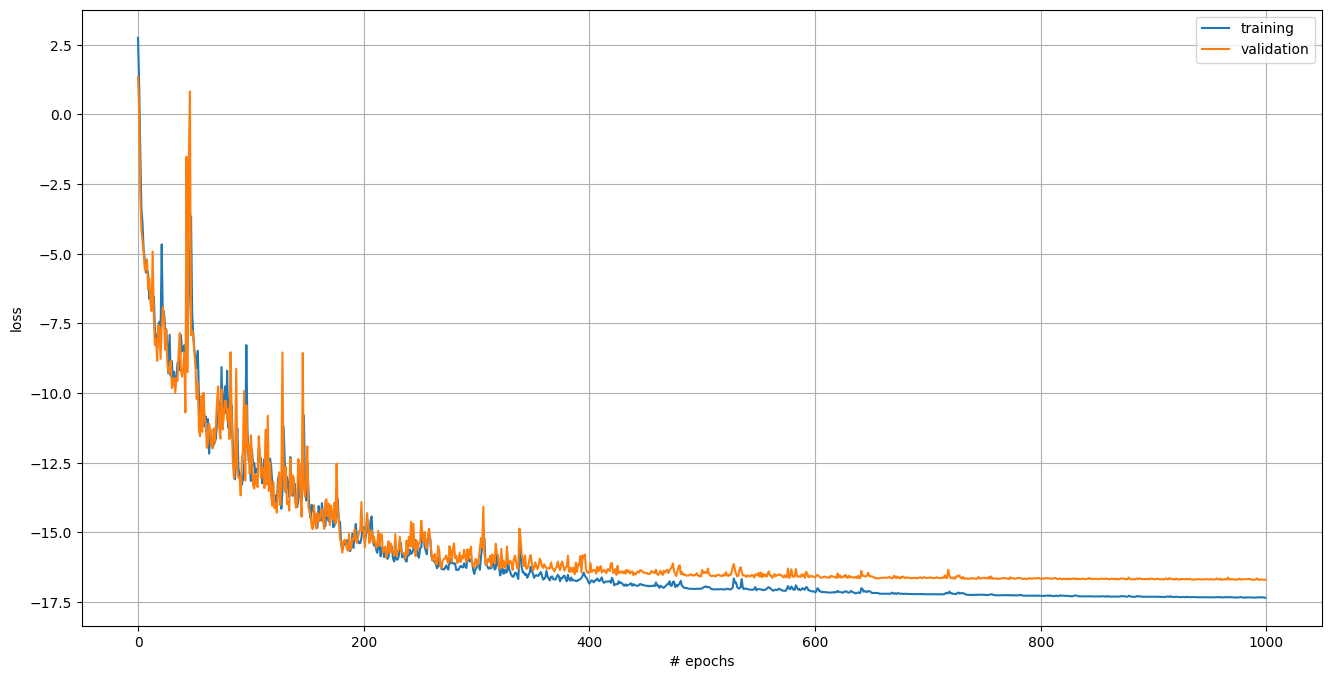

In [29]:
fig, ax = plt.subplots(figsize=(16,8))

ax.plot(fit_history.history["loss"], label="training")
ax.plot(fit_history.history["val_loss"], label="validation")

ax.legend()
ax.set(xlabel="# epochs", ylabel="loss", yscale="linear")
ax.grid(True)

## density estimation tests

In [30]:
# n_cosmos = grid_cosmos.shape[0]
# n_summaries = grid_preds.shape[-1]
# n_samples_per_cosmo = 1000

# pred_samples = model.sample(grid_cosmos, n_samples_per_cond=n_samples_per_cosmo, batch_size=10000)
# print(pred_samples.shape)

In [31]:
# # samples from the mixture model
# mean_samples = np.mean(pred_samples, axis=0)
# std_samples = np.std(pred_samples, axis=0)

# # "true" network predictions
# mean_preds = np.mean(grid_preds, axis=1)
# std_preds = np.std(grid_preds, axis=1)

# assert mean_samples.shape == std_samples.shape == mean_preds.shape == std_preds.shape

# # test statistics, these should be tightly centered around zero
# Delta_mu = (mean_samples - mean_preds)/std_preds
# Delta_sigma = (std_samples - std_preds)/std_preds

# Delta_mu = Delta_mu.ravel()
# Delta_sigma = Delta_sigma.ravel()

# # plot
# fig, ax = plt.subplots(ncols=2, figsize=(16,6), sharey=True)

# ax[0].hist(Delta_mu, bins=50, density=True)
# ax[0].set(title="relative mean statistic", xlabel=r"$\Delta_\mu$", ylabel="probability density")
# ax[0].grid(True)

# ax[1].hist(Delta_sigma, bins=50, density=True)
# ax[1].set(title="relative spread statistic", xlabel=r"$\Delta_\sigma$")
# ax[1].grid(True)

In [32]:
# n_indices = 10

# fig, ax = plt.subplots(figsize=(5*n_summaries, 3*n_indices), nrows=n_indices, ncols=n_summaries, sharex="col", sharey="col")

# cosmo_indices = np.random.randint(0, n_cosmos, n_indices)
# for i, i_cosmo in enumerate(cosmo_indices):
#     for j in range(n_summaries):
#         current_sample = pred_samples[:,i_cosmo,j]
#         current_true = grid_preds[i_cosmo,:,j]
                
#         current_all = np.concatenate([current_sample, current_true]).ravel()
#         current_min = np.quantile(current_all, 0.01)
#         current_max = np.quantile(current_all, 0.99)
#         current_bins = np.linspace(current_min, current_max, 30)

#         ax[i,j].hist(current_sample, bins=current_bins, density=True, label="mixture model samples", alpha=0.5)
#         ax[i,j].hist(current_true, bins=current_bins, density=True, label="summary network predictions", alpha=0.5)

#         # cosmetics
#         ax[i,j].set(title=f"example {i_cosmo}")
#         ax[i,j].grid(True)
        
#         if i==0 and j==0:
#             ax[i,j].legend(loc="upper left")

In [33]:
# n_confidence_levels = 100
# n_examples = grid_preds.shape[1]

# # shape (n_cosmos, n_examples, n_summary)
# true_preds = grid_preds

# # shape (n_cosmos, n_examples)
# true_probs = np.exp(model.log_likelihood(np.repeat(grid_cosmos[:,np.newaxis,:], true_preds.shape[1], axis=1), true_preds))

# # shape (n_cosmos, n_samples_per_cosmo)
# sample_log_probs = model.log_likelihood(np.repeat(grid_cosmos[np.newaxis,:,:], pred_samples.shape[0], axis=0), pred_samples).T

# # empirical expected coverage probability
# eecp = np.zeros((n_cosmos, n_examples, n_confidence_levels))

# # cosmos
# for i in tqdm(range(n_cosmos)):
#     true_cosmo = grid_cosmos[i]
    
#     sample_log_prob = sample_log_probs[i]
#     sample_prob = np.sort(np.exp(sample_log_prob))[::-1]
    
#     # shape (n_conficence_levels,)
#     prob_at_cls = sample_prob[::n_samples_per_cosmo//n_confidence_levels]
    
#     # examples
#     for j in range(n_examples):
#         true_pred = true_preds[i,j]    
#         true_prob = true_probs[i,j]

#         # per cosmology
#         eecp[i,j] = true_prob >= prob_at_cls

# # mean over all cosmologies and examples
# eecp = np.mean(eecp, axis=(0,1))

# # plot
# true_coverage = np.linspace(0, 1, n_confidence_levels)

# fig, ax = plt.subplots()

# ax.plot(true_coverage, eecp, label="Gaussian Mixture Model")
# ax.plot([0, 1], [0, 1], color="k", linestyle="--")

# ax.set(xlabel="True coverage", ylabel="Empirical coverage")
# ax.text(0.2, 0.5, "Conservative", fontsize="large", alpha=0.5, rotation=45)
# ax.text(0.5, 0.2, "Overconfident", fontsize="large", alpha=0.5, rotation=45)
# ax.set_aspect("equal")
# ax.legend(loc="upper left", frameon=False)
# ax.grid(True)

## MCMC

In [34]:
tf_pred = tf.cast(obs_pred, dtype=tf.float32)
tf_pred = tf.expand_dims(tf_pred, axis=0)

def log_likelihood(X): 
    
    print(X.shape)
    
    # evaluate the normal distribution
    log_prob = model.log_likelihood(X, tf_pred)
    
    # enforce the prior
    log_prob = prior.log_posterior(X, log_prob, params=params, conf=conf)

    return log_prob

In [35]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
)

24-01-17 05:41:10      mcmc.py INF   Initial values in prior: True 
(1024, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512, 5)
(512

  0%|          | 1/1000 [00:00<01:45,  9.47it/s]

(512, 5)
(512, 5)
(512, 5)
(512, 5)


  0%|          | 3/1000 [00:00<01:45,  9.44it/s]

(512, 5)
(512, 5)
(512, 5)
(512, 5)


...

(512, 5)
(512, 5)
(512, 5)
(512, 5)


100%|█████████▉| 998/1000 [01:45<00:00,  9.52it/s]

(512, 5)
(512, 5)
(512, 5)
(512, 5)


100%|██████████| 1000/1000 [01:45<00:00,  9.44it/s]


(512, 5)
(512, 5)
(512, 5)


## plot

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

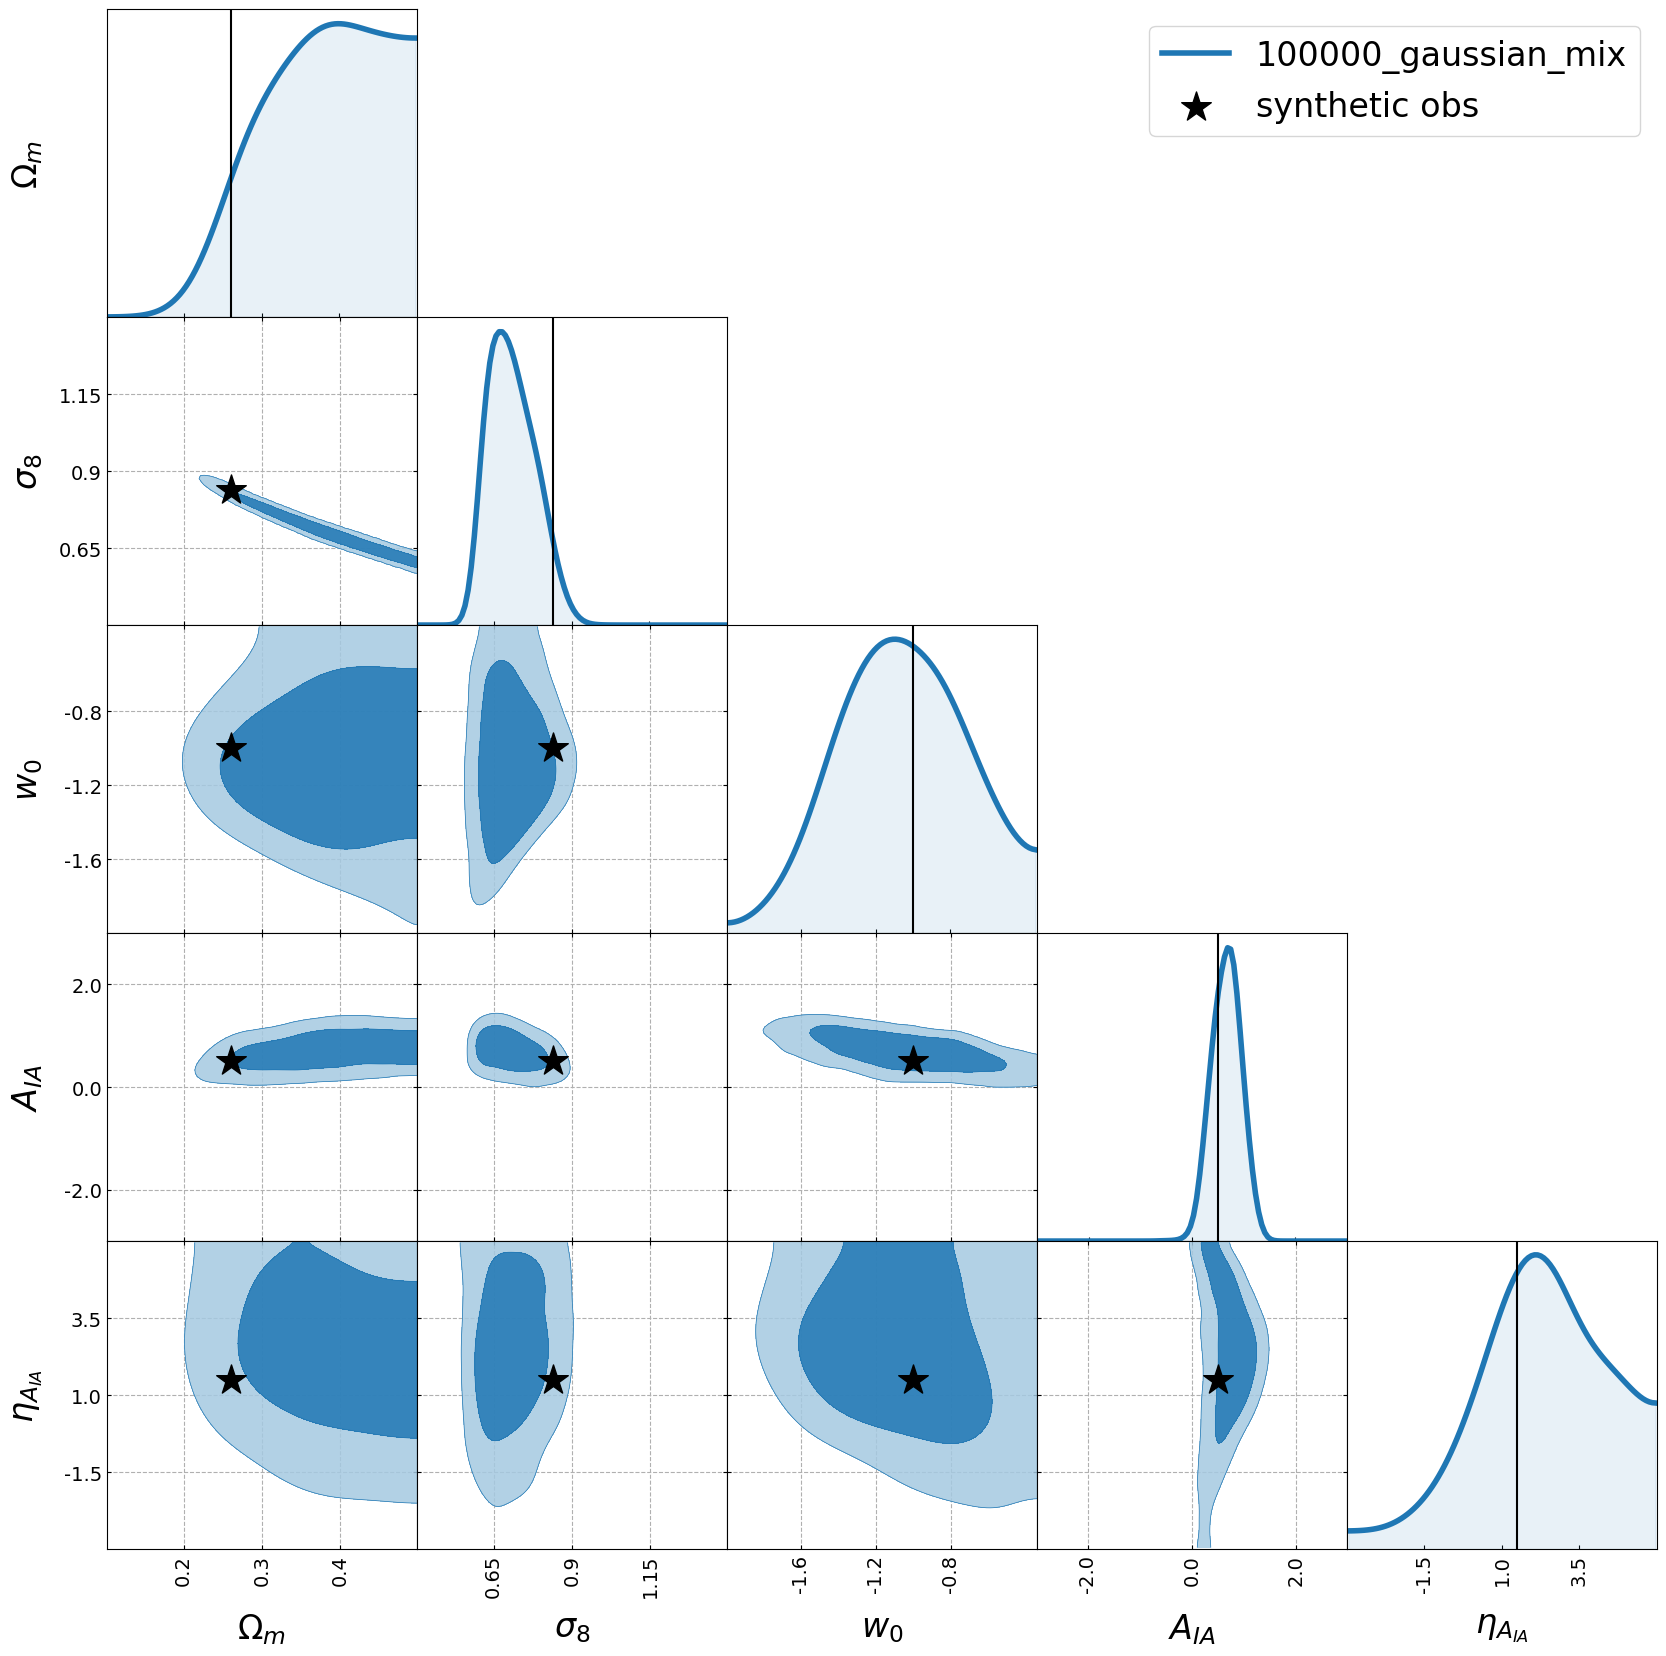

In [36]:
plotting.plot_chains(
    chain, 
    params, 
    conf=conf,
    out_dir=out_dir, 
    labels=label,
    # fiducial_point=fiducial_point,
)